In [15]:
import torch
import time
import numpy as np
from src.utils import make_run_dir, set_seed
from src.dataset import get_downloaders, get_transforms
from src.engine import train_and_evaluate_model, measure_inference_speed
from src.visualization import plot_loss_history, plot_weight_tradeoff, plot_model_comparison_pareto, show_gradcam_grid, plot_model_comparison_bar, plot_confusion_matrix

In [16]:
# 1. 시드 고정 및 디바이스 설정
set_seed(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"현재 사용 중인 디바이스: {device}")

# 2. 이번 실험의 결과물이 저장될 고유 방(폴더) 생성
run_dirs = make_run_dir('./outputs')

현재 사용 중인 디바이스: cuda:0
새로운 실험 결과 폴더가 생성되었습니다: ./outputs\run_20260314_000419


In [17]:
data_dir = './data/new_screw_data' 

# GPU 33GB+ 여유 있으면 batch_size 128~256 권장 (학습 속도 ↑)
dataloaders, image_datasets = get_downloaders(data_dir, batch_size=128)
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes # ['bad', 'good']

print(f"데이터 클래스: {class_names}")
print(f"데이터 개수: Train {dataset_sizes['train']}장 | Val {dataset_sizes['val']}장 | Test {dataset_sizes['test']}장")

데이터 클래스: ['bad', 'good']
데이터 개수: Train 800장 | Val 99장 | Test 100장


In [18]:
bad_weights = np.arange(1.0, 10.5, 0.5).tolist()
best_models_dict = {}
best_f2_scores = []
fps_list = []

In [ ]:
model_name = 'resnet18'

best_model, val_recalls, val_f1s, val_f2_scores, test_y_true, test_y_pred, train_loss, val_loss = train_and_evaluate_model(
    model_name=model_name,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    class_names=class_names,
    device=device,
    run_dirs=run_dirs,
    num_epochs=40 
    )

In [ ]:
best_f2 = max(val_f2_scores)
best_f2_scores.append(best_f2)
best_models_dict[model_name] = best_model

plot_confusion_matrix(test_y_true, test_y_pred, class_names, run_dirs['figures'], model_name=model_name)
plot_loss_history(train_loss, val_loss, run_dirs['figures'], model_name=model_name)
plot_weight_tradeoff(bad_weights, val_recalls, val_f1s, val_f2_scores, run_dirs['figures'], model_name=model_name)

test_transform = get_transforms()['test']
base_test_dir = f'{data_dir}/test'
show_gradcam_grid(best_model, test_transform, base_test_dir, device, run_dirs['figures'], model_name=model_name)

In [ ]:
model_name = 'mobilenet_v2'

best_model, val_recalls, val_f1s, val_f2_scores, test_y_true, test_y_pred, train_loss, val_loss = train_and_evaluate_model(
    model_name=model_name,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    class_names=class_names,
    device=device,
    run_dirs=run_dirs,
    num_epochs=40 
    )

In [ ]:
best_f2 = max(val_f2_scores)
best_f2_scores.append(best_f2)
best_models_dict[model_name] = best_model

plot_confusion_matrix(test_y_true, test_y_pred, class_names, run_dirs['figures'], model_name=model_name)
plot_loss_history(train_loss, val_loss, run_dirs['figures'], model_name=model_name)
plot_weight_tradeoff(bad_weights, val_recalls, val_f1s, val_f2_scores, run_dirs['figures'], model_name=model_name)

test_transform = get_transforms()['test']
base_test_dir = f'{data_dir}/test'
show_gradcam_grid(best_model, test_transform, base_test_dir, device, run_dirs['figures'], model_name=model_name)

In [ ]:
model_name = 'vgg16'

best_model, val_recalls, val_f1s, val_f2_scores, test_y_true, test_y_pred, train_loss, val_loss = train_and_evaluate_model(
    model_name=model_name,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    class_names=class_names,
    device=device,
    run_dirs=run_dirs,
    num_epochs=40 
    )

In [ ]:
best_f2 = max(val_f2_scores)
best_f2_scores.append(best_f2)
best_models_dict[model_name] = best_model

plot_confusion_matrix(test_y_true, test_y_pred, class_names, run_dirs['figures'], model_name=model_name)
plot_loss_history(train_loss, val_loss, run_dirs['figures'], model_name=model_name)
plot_weight_tradeoff(bad_weights, val_recalls, val_f1s, val_f2_scores, run_dirs['figures'], model_name=model_name)

test_transform = get_transforms()['test']
base_test_dir = f'{data_dir}/test'
show_gradcam_grid(best_model, test_transform, base_test_dir, device, run_dirs['figures'], model_name=model_name)


[ RESNET18 모델 평가 ]
측정 결과: 784.4 FPS (1장당 1.27 ms)

[ MOBILENET_V2 모델 평가 ]
측정 결과: 428.2 FPS (1장당 2.34 ms)

[ VGG16 모델 평가 ]
측정 결과: 508.7 FPS (1장당 1.97 ms)


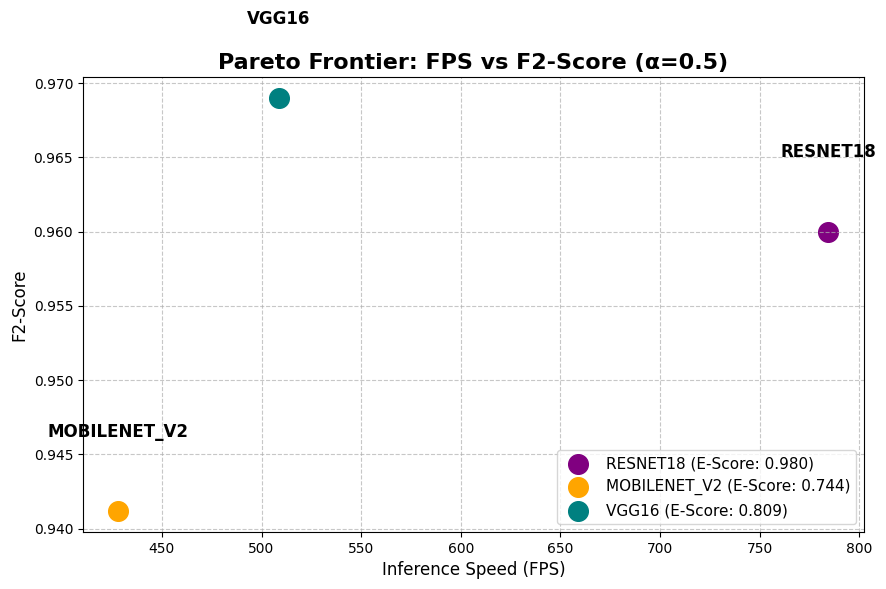

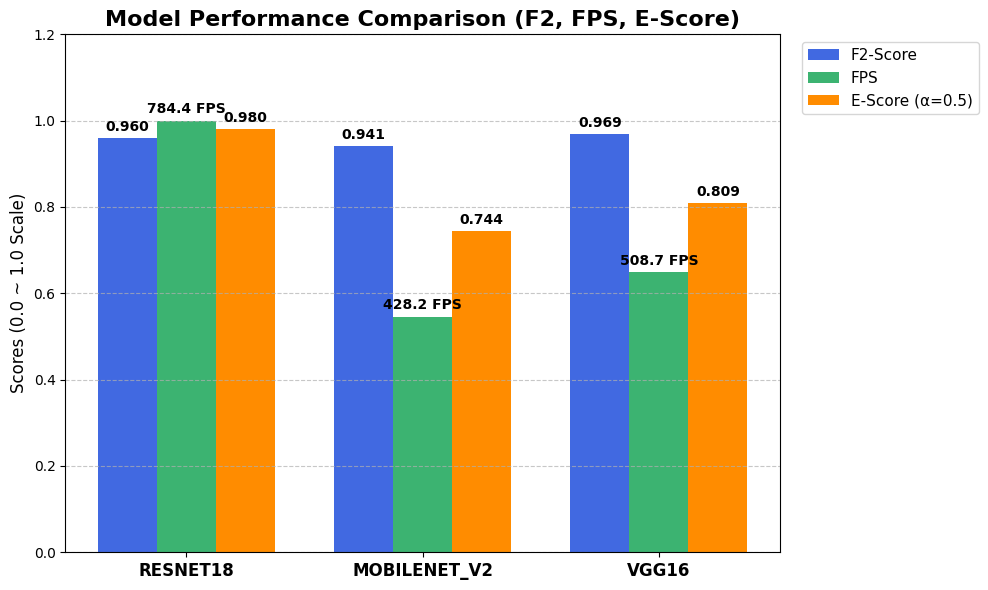

In [27]:
import importlib
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_model_comparison_pareto, plot_model_comparison_bar

for model_name in ['resnet18', 'mobilenet_v2', 'vgg16']:
    print(f"\n[ {model_name.upper()} 모델 평가 ]")
    model = best_models_dict[model_name]
    fps, latency = measure_inference_speed(model, device, num_runs=100)
    fps_list.append(fps)

# GPU 기준 시각화
plot_model_comparison_pareto(
    model_names=['resnet18', 'mobilenet_v2', 'vgg16'], 
    f2_scores=best_f2_scores, 
    fps_list=fps_list, 
    alpha=0.5, 
    save_dir=run_dirs['figures'],
    device_label='GPU'
)
plot_model_comparison_bar(
    model_names=['resnet18', 'mobilenet_v2', 'vgg16'], 
    f2_scores=best_f2_scores, 
    fps_list=fps_list, 
    alpha=0.5,
    save_dir=run_dirs['figures'],
    device_label='GPU'
)

# CPU FPS 측정
device_cpu = torch.device('cpu')
fps_list_cpu = []
for model_name in ['resnet18', 'mobilenet_v2', 'vgg16']:
    model = best_models_dict[model_name]
    model_cpu = model.cpu()
    fps_cpu, _ = measure_inference_speed(model_cpu, device_cpu, num_runs=100)
    fps_list_cpu.append(fps_cpu)
    model.to(device)

# CPU 기준 시각화 (제목·파일명에 CPU 표시)
plot_model_comparison_pareto(
    model_names=['resnet18', 'mobilenet_v2', 'vgg16'], 
    f2_scores=best_f2_scores, 
    fps_list=fps_list_cpu, 
    alpha=0.5, 
    save_dir=run_dirs['figures'],
    device_label='CPU'
)
plot_model_comparison_bar(
    model_names=['resnet18', 'mobilenet_v2', 'vgg16'], 
    f2_scores=best_f2_scores, 
    fps_list=fps_list_cpu, 
    alpha=0.5,
    save_dir=run_dirs['figures'],
    device_label='CPU'
)

측정 결과: 106.0 FPS (1장당 9.43 ms)
resnet18: CPU 106.0 FPS
측정 결과: 105.3 FPS (1장당 9.50 ms)
mobilenet_v2: CPU 105.3 FPS
측정 결과: 26.3 FPS (1장당 37.96 ms)
vgg16: CPU 26.3 FPS


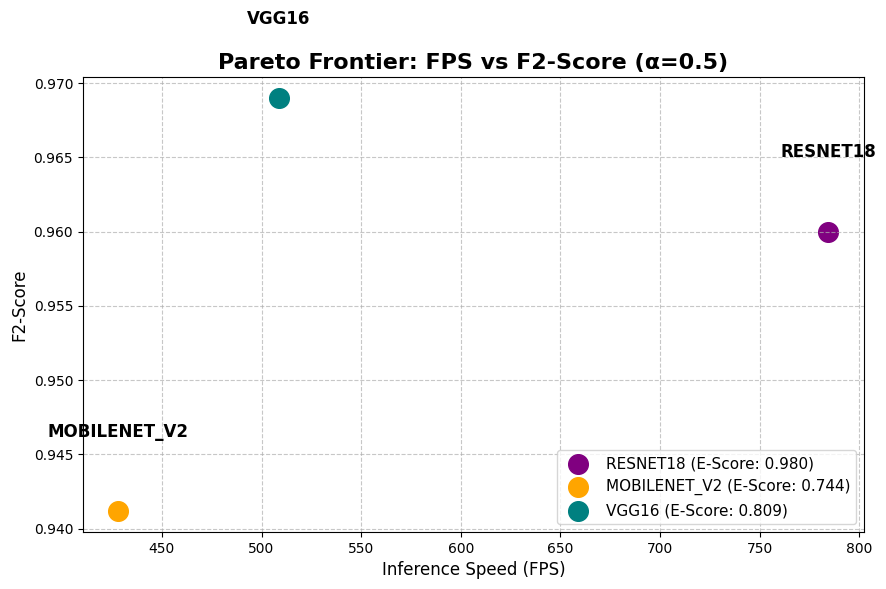

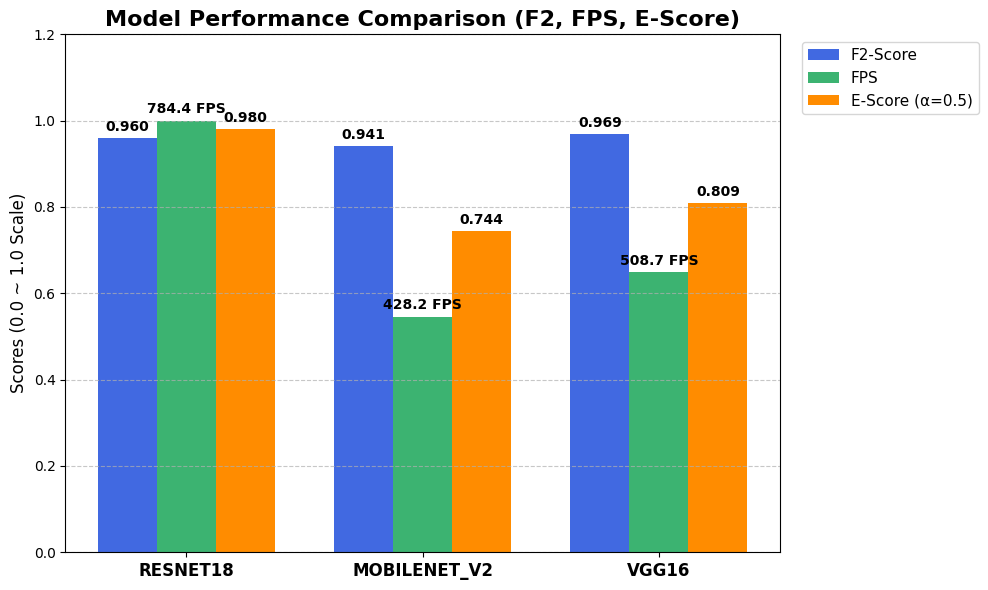

In [ ]:
# CPU에서 FPS 측정 (비교용)
device_cpu = torch.device('cpu')
for model_name in ['resnet18', 'mobilenet_v2', 'vgg16']:
    model = best_models_dict[model_name]
    model_cpu = model.cpu()  # 잠시 CPU로
    fps_cpu, latency_cpu = measure_inference_speed(model_cpu, device_cpu, num_runs=100)
    print(f"{model_name}: CPU {fps_cpu:.1f} FPS")
    model.to(device)  # 다시 GPU로 (다음 학습 등에 영향 없도록)

# plot_model_comparison_pareto(
#     model_names=['resnet18', 'mobilenet_v2', 'vgg16'], 
#     f2_scores=best_f2_scores, 
#     fps_list=fps_list, 
#     alpha=0.5, 
#     save_dir=run_dirs['figures']
# )

# plot_model_comparison_bar(
#     model_names=['resnet18', 'mobilenet_v2', 'vgg16'], 
#     f2_scores=best_f2_scores, 
#     fps_list=fps_list, 
#     alpha=0.5, # 0.5면 정확도와 속도를 5:5 비율로 평가하겠다는 뜻
#     save_dir=run_dirs['figures']
# )